# PTCG Scanner — full pipeline (photo → OCR → catalog)

End-to-end, **no training**. Default eval is **`data/identify/`** (Roboflow OBB whose class name is `SET  number  name`).

1. Detect each card (**obb-v6**, YOLOv26s) and crop 63×88 mm (`orient_portrait` fixes 90°).
2. ROI at **0° and 180°**; keep printed-up (`name` above `number`); RapidOCR for every script in `data/catalog/` (Latin, Japanese, Chinese, Korean, Russian). Column `orient_deg` in the extract CSV.
3. Nearest card in `data/catalog/{lang}/`.
4. Score against identify labels: match predicted OBB to GT OBB by **IoU ≥ 0.5** (not CSV row order).

Set `EVAL_SOURCE = "input"` to go back to `data/input/` + sibling CSV.

Outputs: CSVs in `output/` and three report PDFs in `output/pdfs/` — OBB, catalog hits, catalog misses (ROI boxes drawn on the crops). A GPU helps YOLO.


In [21]:
from __future__ import annotations

import importlib
import re
import shutil
import sys
import unicodedata
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
import pymupdf
import torch
from IPython.display import Markdown, display, update_display
from ultralytics import YOLO

def find_repo() -> Path:
    here = Path(".").resolve()
    for p in [here, *here.parents]:
        if (p / "src" / "cropper" / "rectify.py").is_file() and (p / "src" / "detection").is_dir():
            return p
    raise FileNotFoundError(
        "Open this notebook from the PTCG Scanner repo (folders src/cropper/ and src/detection/)."
    )


REPO = find_repo()

sys.path.insert(0, str(REPO / "src" / "cropper"))
sys.path.insert(0, str(REPO / "src" / "ocr"))

from crop_from_obb import imgsz_for_weights
from rectify import crop_result
import read_card
importlib.reload(read_card)
from read_card import catalog_language_codes, create_reader, fold_text, read_card, script_family

DATA = REPO / "data"
EVAL_SOURCE = "identify"  # "identify" | "input"
IDENTIFY_DIR = DATA / "identify"
IDENTIFY_SPLIT = "test"
MAX_IMAGES = None  # e.g. 20 for a smoke test
IOU_THR = 0.5
IDENTIFY_MODE = EVAL_SOURCE == "identify"
if IDENTIFY_MODE:
    INPUT_DIR = IDENTIFY_DIR / IDENTIFY_SPLIT / "images"
    SAVE_STAGES = False
    SEC_PER_PAGE = 2
else:
    INPUT_DIR = DATA / "input"
    SAVE_STAGES = True
    SEC_PER_PAGE = 20
INPUT_DIR.mkdir(parents=True, exist_ok=True)
CATALOG_LANG = "en"  # matching catalog; OCR scripts come from every folder in data/catalog/
CATALOG_DIR = DATA / "catalog" / CATALOG_LANG
CATALOG_CSV = CATALOG_DIR / "cards.csv"
SETS_CSV = CATALOG_DIR / "sets.csv"
OUT_DIR = REPO / "output"
OUT_PDF_DIR = OUT_DIR / "pdfs"
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_PDF_DIR.mkdir(parents=True, exist_ok=True)

OBB_WEIGHTS = REPO / "src" / "detection" / "runs" / "obb" / "obb-v6" / "weights" / "obb-v6.pt"
_roi_runs = REPO / "src" / "roi" / "runs"
_roi_v3 = _roi_runs / "ocr-roi-v3" / "weights" / "ocr-roi-v3.pt"
_roi_v2 = _roi_runs / "ocr-roi-v2" / "weights" / "ocr-roi-v2.pt"
_roi_v1 = _roi_runs / "ocr-roi-v1" / "weights" / "ocr-roi-v1.pt"
OCR_WEIGHTS = next((p for p in (_roi_v3, _roi_v2, _roi_v1) if p.is_file()), _roi_v3)
CARD_CONF = 0.8
OCR_CONF = 0.4
PDF_DPI = 200
DEVICE = 0 if torch.cuda.is_available() else "cpu"
JPEG_QUALITY = 85
CROP_CELL = (372, 520)


def fold(text: str) -> str:
    return fold_text(text)


def parse_number(text: str) -> tuple[int | None, int | None]:
    match = re.search(r"(\d+)\s*[/-]\s*(\d+)", text or "")
    if match:
        return int(match.group(1)), int(match.group(2))
    digits = re.sub(r"\D", "", text or "")
    if len(digits) >= 3:
        return int(digits[:3]), int(digits[3:]) if len(digits) > 3 else None
    return None, None


def format_number(collector: int | None, total: int | None) -> str:
    if collector is None:
        return ""
    if total is None:
        return str(collector)
    return f"{collector}/{total}"


print("Repo     :", REPO)
print("Eval     :", EVAL_SOURCE, "| MAX_IMAGES=", MAX_IMAGES)
print("Input    :", INPUT_DIR, "exists=", INPUT_DIR.is_dir())
print("Catalog  :", CATALOG_LANG, CATALOG_CSV, "exists=", CATALOG_CSV.is_file())
print("Sets     :", SETS_CSV, "exists=", SETS_CSV.is_file())
print("Output   :", OUT_DIR)
print("OBB      :", OBB_WEIGHTS, "exists=", OBB_WEIGHTS.is_file())
print("OCR ROI  :", OCR_WEIGHTS, "exists=", OCR_WEIGHTS.is_file())
print("Device   :", DEVICE)


Repo     : C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao
Eval     : identify | MAX_IMAGES= None
Input    : C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\data\identify\test\images exists= True
Catalog  : en C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\data\catalog\en\cards.csv exists= True
Sets     : C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\data\catalog\en\sets.csv exists= True
Output   : C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\output
OBB      : C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\src\detection\runs\obb\obb-v6\weights\obb-v6.pt exists= True
OCR ROI  : C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\src\roi\runs\ocr-roi-v3\weights\ocr-roi-v3.pt exists= True
Device   : 0


## 1. Catalog (`data/catalog/`)

One row per card in `data/catalog/{lang}/cards.csv`: `Name`, `Number`, `Rarity`, `setId`. Identify GT uses the printed set code in the class name (e.g. `JTG 181-159 Ruffian`); the catalog is **not** restricted to a single file setId in that mode.


In [22]:
def load_catalog(csv_path: Path, sets_path: Path) -> pd.DataFrame:
    raw = pd.read_csv(csv_path)
    cols = {c.lower(): c for c in raw.columns}
    if "name" not in cols or "number" not in cols or "setid" not in cols:
        raise ValueError(f"Catalog needs Name, Number, setId: {csv_path}")
    sets = pd.read_csv(sets_path)
    name_by_id = dict(zip(sets["id"].astype(str), sets["name"].astype(str)))
    rows = []
    for _, row in raw.iterrows():
        name = str(row[cols["name"]]).strip()
        number = str(row[cols["number"]]).strip()
        rarity = str(row[cols["rarity"]]).strip() if "rarity" in cols else ""
        set_id = str(row[cols["setid"]]).strip()
        collector, total = parse_number(number)
        rows.append(
            {
                "name": name,
                "number": number,
                "rarity": rarity,
                "set_id": set_id,
                "set_code": set_id,
                "set_name": name_by_id.get(set_id, set_id),
                "set_file": set_id,
                "collector": collector,
                "total": total,
                "name_fold": fold(name),
            }
        )
    catalog = pd.DataFrame(rows)
    catalog = catalog.drop_duplicates(subset=["name_fold", "number", "set_id"], keep="first")
    catalog["script"] = catalog["name_fold"].map(script_family)
    return catalog.reset_index(drop=True)


def load_catalogs(catalog_root: Path, preferred: str = "en") -> pd.DataFrame:
    langs = catalog_language_codes(catalog_root)
    if preferred in langs:
        langs = [preferred] + [lang for lang in langs if lang != preferred]
    frames = []
    for lang in langs:
        csv_path = catalog_root / lang / "cards.csv"
        sets_path = catalog_root / lang / "sets.csv"
        if not csv_path.is_file() or not sets_path.is_file():
            continue
        frame = load_catalog(csv_path, sets_path)
        frame["lang"] = lang
        frames.append(frame)
    if not frames:
        raise FileNotFoundError(f"No catalogs in {catalog_root}")
    catalog = pd.concat(frames, ignore_index=True)
    catalog = catalog.drop_duplicates(subset=["name_fold", "number", "set_id"], keep="first")
    return catalog.reset_index(drop=True)


catalog = load_catalogs(DATA / "catalog", CATALOG_LANG)
print(f"{len(catalog):,} cartas em {catalog['set_id'].nunique()} sets | langs={sorted(catalog['lang'].unique())}")
print(catalog.sample(min(5, len(catalog)), random_state=0)[["name", "number", "set_id", "set_name", "lang"]])


60,777 cartas em 167 sets | langs=['de', 'en', 'es', 'fr', 'it', 'ja', 'pt', 'zh-cn', 'zh-tw']
                     name       number set_id               set_name lang
58005        Maca Noturna      196/217    ASC        Heróis Excelsos   pt
58548              Tomila      143/131    PRE  Evoluções Prismáticas   pt
51278             Ronflex  SWSH032/307  SWSHP             Promo SWSH   fr
37873  Carta del Profesor     146a/162    BKT          Turbo Impulso   es
47966          Manglouton      109/149    SUM         Soleil et Lune   fr


## 2. Jobs and ground truth

**identify:** images in `data/identify/test/images`, labels in `labels/`. Class string = `SET  collector-total  name`. Illegible names (`---`) keep set+number.

**input:** photos/PDFs in `data/input/` plus optional sibling CSV (`name`, `number`, `setId`) paired in row order.


In [23]:
_ILLEGIBLE_NAME = re.compile(r"^[-_.\s]*(?:v|ex|gx|vstar|vmax)?[-_.\s]*$", re.I)


def parse_identify_label(text: str) -> dict:
    raw = (text or "").strip()
    parts = raw.split(None, 2)
    collection = parts[0] if parts else ""
    number_tok = parts[1] if len(parts) > 1 else ""
    name = parts[2] if len(parts) > 2 else ""
    compact = re.sub(r"[^A-Za-z0-9]", "", name)
    if (not name.strip()) or _ILLEGIBLE_NAME.fullmatch(name.replace(" ", "")) or (
        name.count("-") >= 2 and len(compact) <= 4
    ):
        name = ""
    return {"name": name, "number": number_tok.replace("-", "/"), "collection": collection}


def load_jobs(input_dir: Path) -> list[dict]:
    suffixes = {".pdf", ".jpg", ".jpeg", ".png", ".webp", ".bmp", ".tif", ".tiff"}
    jobs = []
    if not input_dir.is_dir():
        return jobs
    for path in sorted(input_dir.iterdir()):
        if path.suffix.lower() not in suffixes:
            continue
        csv_path = path.with_suffix(".csv")
        set_id = ""
        if (not IDENTIFY_MODE) and csv_path.is_file():
            frame = pd.read_csv(csv_path)
            cols = {c.lower(): c for c in frame.columns}
            if "setid" in cols and len(frame):
                set_id = str(frame[cols["setid"]].iloc[0]).strip()
        jobs.append({"source": path, "csv": csv_path, "set_id": set_id})
    if MAX_IMAGES is not None:
        jobs = jobs[: int(MAX_IMAGES)]
    return jobs


def load_truth_csv(jobs: list[dict]) -> pd.DataFrame:
    rows = []
    for job in jobs:
        csv_path = job["csv"]
        if not csv_path.is_file():
            continue
        raw = pd.read_csv(csv_path)
        cols = {c.lower(): c for c in raw.columns}
        for _, row in raw.iterrows():
            number = str(row[cols["number"]]).strip() if "number" in cols else ""
            collector, total = parse_number(number)
            rows.append(
                {
                    "image": job["source"].name,
                    "name": str(row[cols["name"]]).strip() if "name" in cols else "",
                    "number": number,
                    "collection": str(row[cols["setid"]]).strip() if "setid" in cols else job["set_id"],
                    "collector": collector,
                    "total": total,
                }
            )
    return pd.DataFrame(rows)


def load_identify_truth(jobs: list[dict]) -> pd.DataFrame:
    yaml_path = IDENTIFY_DIR / "data.yaml"
    if not yaml_path.is_file():
        raise FileNotFoundError(f"Unzip the Roboflow identify dataset into {IDENTIFY_DIR}")
    data = yaml.safe_load(yaml_path.read_text(encoding="utf-8"))
    names = data["names"]
    class_names = (
        {int(k): str(v) for k, v in names.items()}
        if isinstance(names, dict)
        else {i: str(name) for i, name in enumerate(names)}
    )
    lab_dir = IDENTIFY_DIR / IDENTIFY_SPLIT / "labels"
    rows = []
    for job in jobs:
        path = job["source"]
        lab = lab_dir / f"{path.stem}.txt"
        bgr = cv2.imread(str(path))
        if bgr is None or not lab.is_file():
            continue
        h, w = bgr.shape[:2]
        for box_i, line in enumerate(lab.read_text(encoding="utf-8").splitlines()):
            parts = line.split()
            if len(parts) < 9:
                continue
            parsed = parse_identify_label(class_names.get(int(float(parts[0])), ""))
            pts = np.array(list(map(float, parts[1:9])), dtype=np.float32).reshape(4, 2)
            pts[:, 0] *= w
            pts[:, 1] *= h
            collector, total = parse_number(parsed["number"])
            rows.append(
                {
                    "image": path.name,
                    "box_i": box_i,
                    "name": parsed["name"],
                    "number": parsed["number"],
                    "collection": parsed["collection"],
                    "collector": collector,
                    "total": total,
                    "quad": pts,
                    "gt_raw": class_names.get(int(float(parts[0])), ""),
                }
            )
    return pd.DataFrame(rows)


jobs = load_jobs(INPUT_DIR)
truth = load_identify_truth(jobs) if IDENTIFY_MODE else load_truth_csv(jobs)
print(f"{len(jobs)} file(s)  |  {len(truth)} annotated card(s)  |  source={EVAL_SOURCE}")
if not IDENTIFY_MODE:
    for job in jobs[:12]:
        print(f"  {job['source'].name}  setId={job['set_id'] or '-'}  csv={job['csv'].is_file()}")
    if len(jobs) > 12:
        print(f"  ... {len(jobs) - 12} more")
if truth.empty:
    print("No ground truth — extract and catalog match only.")
else:
    show = truth.drop(columns=["quad"], errors="ignore")
    display(show.head(12))


500 file(s)  |  3476 annotated card(s)  |  source=identify


,image,box_i,name,number,collection,collector,total,gt_raw
0,0079_jpg.rf.0ef91d0ab65ea2bb722814182fe00e54.jpg,0,Tranquill,72/86,BLK,72,86,BLK 72-86 Tranquill
1,0079_jpg.rf.0ef91d0ab65ea2bb722814182fe00e54.jpg,1,Unfezant,73/86,BLK,73,86,BLK 73-86 Unfezant
2,0079_jpg.rf.0ef91d0ab65ea2bb722814182fe00e54.jpg,2,Diggersby,65/88,POR,65,88,POR 65-88 Diggersby
3,0079_jpg.rf.0ef91d0ab65ea2bb722814182fe00e54.jpg,3,Larry-s Starly,168/217,ASC,168,217,ASC 168-217 Larry-s Starly
4,0079_jpg.rf.0ef91d0ab65ea2bb722814182fe00e54.jpg,4,Larry-s Staravia,169/217,ASC,169,217,ASC 169-217 Larry-s Staravia
5,0079_jpg.rf.0ef91d0ab65ea2bb722814182fe00e54.jpg,5,Larry-s Staraptor,170/217,ASC,170,217,ASC 170-217 Larry-s Staraptor
6,0079_jpg.rf.0ef91d0ab65ea2bb722814182fe00e54.jpg,6,Lopunny,108/132,MEG,108,132,MEG 108-132 Lopunny
7,0079_jpg.rf.0ef91d0ab65ea2bb722814182fe00e54.jpg,7,Skitty,165/217,ASC,165,217,ASC 165-217 Skitty
8,0079_jpg.rf.0ef91d0ab65ea2bb722814182fe00e54.jpg,8,Larry-s Komala,175/217,ASC,175,217,ASC 175-217 Larry-s Komala
9,0089_jpg.rf.a883ea0a002c40f7f50dcc93e92bee70.jpg,0,N-s Sigilyph,64/159,JTG,64,159,JTG 64-159 N-s Sigilyph


## 3. Nearest card in the catalog

Priority: **name**, then **number**, then **collection**. On identify pages the cards mix sets, so `set_id` on the job stays empty and the OCR set code only *boosts* the catalog score.


In [24]:
from difflib import SequenceMatcher

_STOPWORDS = {
    "de", "da", "do", "dos", "das", "e", "o", "a", "os", "as",
    "the", "of", "and", "s", "lv",
}
_WORD_EN = {
    "castelo": "castle",
    "espirito": "spirit",
    "luta": "fighting",
    "busca": "scouting",
    "bolsa": "bag",
    "faixa": "band",
    "escolha": "choice",
    "treino": "training",
    "perola": "pearl",
    "lilian": "lillie",
    "lillian": "lillie",
    "lilies": "lillie",
    "lupo": "hop",
    "vastro": "vstar",
    "preta": "black",
    "hisui": "hisuian",
}


def folded_words(text: str) -> list[str]:
    text = (text or "").replace("'s", " ").replace("’s", " ").replace(".", " ")
    words: list[str] = []
    for word in re.split(r"[^\w]+", text, flags=re.UNICODE):
        folded = fold(word)
        if not folded:
            continue
        match = re.match(r"^(.+?)(vstar|vastro|vmax|ex|gx)$", folded)
        if match and len(match.group(1)) >= 3:
            words.extend([match.group(1), match.group(2)])
        else:
            words.append(folded)
    return words


def name_tokens(text: str) -> set[str]:
    tokens = set()
    for word in folded_words(text):
        if word in _STOPWORDS or len(word) <= 1:
            continue
        tokens.add(_WORD_EN.get(word, word))
    return tokens


def edit_distance(left: str, right: str, limit: int = 2) -> int:
    """Distancia de edicao. A comparacao ja esta em minusculas."""
    if left == right:
        return 0
    if abs(len(left) - len(right)) > limit:
        return limit + 1
    if len(left) > len(right):
        left, right = right, left
    previous = list(range(len(right) + 1))
    for index, char in enumerate(left, start=1):
        current = [index]
        row_min = index
        for column, other in enumerate(right, start=1):
            cost = 0 if char == other else 1
            best = min(current[column - 1] + 1, previous[column] + 1, previous[column - 1] + cost)
            current.append(best)
            if best < row_min:
                row_min = best
        if row_min > limit:
            return limit + 1
        previous = current
    return previous[-1]


def similar_name(left: str, right: str) -> bool:
    """Uma letra a mais, a menos ou trocada. Nomes muito curtos nao aceitam troca."""
    if not left or not right or left == right:
        return left == right and bool(left)
    if edit_distance(left, right, 1) > 1:
        return False
    shortest = min(len(left), len(right))
    if abs(len(left) - len(right)) == 1:
        return shortest >= 4
    return shortest >= 5


def names_equivalent(a: str, b: str) -> bool:
    """PT e EN, e um erro de uma letra, contam como o mesmo nome."""
    if not str(a or "").strip() or not str(b or "").strip():
        return False
    left_fold, right_fold = fold(a), fold(b)
    if left_fold == right_fold or similar_name(left_fold, right_fold):
        return True
    left, right = name_tokens(a), name_tokens(b)
    if not left or not right:
        return SequenceMatcher(None, left_fold, right_fold).ratio() >= 0.8
    inter = left & right
    if not inter:
        return SequenceMatcher(None, left_fold, right_fold).ratio() >= 0.8
    if left <= right or right <= left:
        return True
    jacc = len(inter) / len(left | right)
    if jacc >= 0.5 and any(len(token) >= 4 for token in inter):
        return True
    return jacc >= 0.66 or SequenceMatcher(None, left_fold, right_fold).ratio() >= 0.8


def name_score(ocr_name: str, cat_fold: str, cat_name: str) -> float:
    query = fold(ocr_name)
    if not query or not cat_fold:
        return 0.0
    q_fam, c_fam = script_family(query), script_family(cat_fold)
    if q_fam != "none" and c_fam != "none" and q_fam != c_fam:
        return 0.0
    distance = edit_distance(query, cat_fold, 2)
    if similar_name(query, cat_fold) or (cat_name and names_equivalent(ocr_name, cat_name)):
        return 1.0
    if distance == 2:
        return 0.9
    if query in cat_fold or cat_fold in query:
        return 0.88
    return SequenceMatcher(None, query, cat_fold).ratio()


def match_catalog(
    ocr_name: str,
    ocr_number: str,
    ocr_collection: str,
    catalog: pd.DataFrame,
    set_id: str = "",
    top_n: int = 3,
) -> pd.DataFrame:
    """Nome pesa mais que o numero, e o numero mais que a colecao."""
    # 0.1 a mais no nome (100) supera numero e colecao juntos (85).
    name_w, name_exact = 1000.0, 40.0
    number_w, number_near, total_w, set_w = 50.0, 15.0, 25.0, 10.0
    collector, total = parse_number(ocr_number)
    query = fold(ocr_name)
    collection_ids = set()
    if set_id:
        collection_ids.add(set_id)
    ocr_set = (ocr_collection or "").strip()
    if ocr_set and ocr_set in set(catalog["set_id"]):
        collection_ids.add(ocr_set)

    parts = []
    q_fam = script_family(query) if query else "none"
    names = catalog if q_fam in ("none", "") else catalog.loc[catalog["script"] == q_fam]
    if query:
        exact = names.loc[names["name_fold"] == query]
        if len(exact):
            parts.append(exact)
        else:
            close = names["name_fold"].map(lambda folded: edit_distance(query, folded, 2) <= 2)
            parts.append(names.loc[close])
    if collector is not None:
        near_cat = names if query else catalog
        near = near_cat["collector"].notna() & (near_cat["collector"] - collector).abs().le(2)
        parts.append(near_cat.loc[near])
    if not parts and collection_ids:
        parts.append(catalog.loc[catalog["set_id"].isin(collection_ids)])
    pool = catalog if not parts else pd.concat(parts).drop_duplicates()
    if pool.empty:
        pool = catalog

    scored = pool.copy()
    scores = np.zeros(len(scored), dtype=np.float32)
    scores += np.asarray(
        [name_w * name_score(ocr_name, folded, cat_name) for folded, cat_name in zip(scored["name_fold"], scored["name"])],
        dtype=np.float32,
    )
    if query:
        scores += np.where(scored["name_fold"].to_numpy() == query, name_exact, 0.0)
    if collector is not None:
        same = scored["collector"].to_numpy() == collector
        scores += np.where(same, number_w, 0.0)
        near = scored["collector"].notna().to_numpy() & (np.abs(scored["collector"].to_numpy() - collector) <= 2)
        scores += np.where(near & ~same, number_near, 0.0)
        if total is not None:
            scores += np.where(scored["total"].to_numpy() == total, total_w, 0.0)
    if collection_ids:
        scores += np.where(scored["set_id"].isin(collection_ids).to_numpy(), set_w, 0.0)
    scored["score"] = scores
    out = scored.sort_values("score", ascending=False).head(top_n)
    return out.reset_index(drop=True)


demo = match_catalog("Alakazam", "1/102", "", catalog, set_id="BS", top_n=3)
display(demo[["name", "number", "set_id", "set_name", "rarity", "score"]])


,name,number,set_id,set_name,rarity,score
0,Alakazam,1/102,BS,Base Set,Rare Holo,1125.0
1,Alakazam,1/110,LC,Legendary Collection,Rare Holo,1090.0
2,Alakazam,1/165,EX,Expedition Base Set,Rare Holo,1090.0


## 4. Models

Card detector **obb-v6** (YOLOv26s) + strip detector **ocr-roi-v3** + RapidOCR (Latin, Japanese, Chinese, Korean, Russian from `data/catalog/`).


In [25]:
assert OBB_WEIGHTS.is_file(), f"OBB weights not found: {OBB_WEIGHTS}"
assert OCR_WEIGHTS.is_file(), f"OCR weights not found: {OCR_WEIGHTS}"
assert jobs, f"No photos or PDFs in {INPUT_DIR}"

card_model = YOLO(str(OBB_WEIGHTS))
roi_model = YOLO(str(OCR_WEIGHTS))
reader = create_reader(DATA / "catalog")
OBB_IMGSZ = imgsz_for_weights(OBB_WEIGHTS)
print("OBB imgsz", OBB_IMGSZ, "| OCR RapidOCR langs=", getattr(reader, "langs", ()))


OBB imgsz 960 | OCR RapidOCR langs= ['de', 'en', 'es', 'fr', 'id', 'it', 'ja', 'ko', 'nl', 'pl', 'pt', 'pt-pt', 'ru', 'zh-cn', 'zh-tw']


## 5. Extract cards

Detect → crop 63×88 mm → ROI at **0° and 180°** (keep printed-up) → RapidOCR → catalog. Writes `output/pdfs/01_obb.pdf` (boxes on each photo). ROI boxes are drawn later on `03_acertos.pdf` and `03_erros.pdf`. Progress: `imagens x/y` and `cartas`.


In [26]:
def sort_crops(crops, image_shape) -> list:
    h = max(int(image_shape[0]), 1)
    row_h = max(h / 4.0, 40.0)

    def key(card):
        cy = float(card.quad[:, 1].mean())
        cx = float(card.quad[:, 0].mean())
        return (int(cy / row_h), cx)

    return sorted(crops, key=key)


def card_to_bgr(card) -> np.ndarray:
    img = card.image
    if img.ndim == 2:
        return cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    return img


_ROI_NAME_KEYS = {"name"}
_ROI_NUMBER_KEYS = {"number"}


def _roi_class_ids(pred, keys: set[str]) -> set[int]:
    names = getattr(pred, "names", None) or {}
    ids = set()
    for cid, label in names.items():
        if str(label).lower() in keys:
            ids.add(int(cid))
    return ids


def _roi_best_cy(pred, keys: set[str]) -> float | None:
    boxes = getattr(pred, "obb", None) or getattr(pred, "boxes", None)
    if boxes is None or len(boxes) == 0:
        return None
    target = _roi_class_ids(pred, keys)
    if not target:
        return None
    cls = boxes.cls.detach().cpu().numpy()
    conf = boxes.conf.detach().cpu().numpy()
    if hasattr(boxes, "xyxyxyxy") and boxes.xyxyxyxy is not None:
        pts = boxes.xyxyxyxy.detach().cpu().numpy().reshape(len(boxes), -1, 2)
        cy = pts[:, :, 1].mean(axis=1)
    else:
        xyxy = boxes.xyxy.detach().cpu().numpy()
        cy = (xyxy[:, 1] + xyxy[:, 3]) / 2.0
    best_conf = -1.0
    best_cy = None
    for i, cid in enumerate(cls):
        if int(cid) not in target:
            continue
        if float(conf[i]) > best_conf:
            best_conf = float(conf[i])
            best_cy = float(cy[i])
    return best_cy


def upright_layout_score(pred, height: int) -> float:
    """Positive when name is above number (printed-up TCG layout)."""
    h = max(float(height), 1.0)
    name_y = _roi_best_cy(pred, _ROI_NAME_KEYS)
    number_y = _roi_best_cy(pred, _ROI_NUMBER_KEYS)
    if name_y is not None and number_y is not None:
        return (number_y - name_y) / h
    if name_y is not None:
        return 0.5 - name_y / h
    if number_y is not None:
        return number_y / h - 0.5
    return 0.0


def predict_roi(bgr: np.ndarray):
    return roi_model.predict(
        source=bgr,
        conf=OCR_CONF,
        imgsz=800,
        device=DEVICE,
        verbose=False,
    )[0]


def orient_printed_up(crop_color: np.ndarray, crop_bgr: np.ndarray):
    """Keep 0° unless 180° clearly puts name above number."""
    flipped_bgr = cv2.rotate(crop_bgr, cv2.ROTATE_180)
    flipped_color = cv2.rotate(crop_color, cv2.ROTATE_180)
    roi0 = predict_roi(crop_bgr)
    roi180 = predict_roi(flipped_bgr)
    s0 = upright_layout_score(roi0, crop_bgr.shape[0])
    s180 = upright_layout_score(roi180, flipped_bgr.shape[0])
    if s180 > s0 + 0.05:
        return flipped_color, flipped_bgr, roi180, 180
    return crop_color, crop_bgr, roi0, 0


def rasterize_pdf(path: Path, dpi: int = PDF_DPI) -> list[np.ndarray]:
    doc = pymupdf.open(path)
    zoom = dpi / 72.0
    matrix = pymupdf.Matrix(zoom, zoom)
    pages = []
    for page in doc:
        pix = page.get_pixmap(matrix=matrix, alpha=False)
        arr = np.frombuffer(pix.samples, dtype=np.uint8).reshape(pix.height, pix.width, pix.n)
        if pix.n == 3:
            arr = cv2.cvtColor(arr, cv2.COLOR_RGB2BGR)
        elif pix.n == 4:
            arr = cv2.cvtColor(arr, cv2.COLOR_RGBA2BGR)
        pages.append(arr)
    doc.close()
    return pages


def bgr_to_jpeg_bytes(bgr: np.ndarray, quality: int = JPEG_QUALITY) -> bytes:
    ok, buf = cv2.imencode(".jpg", bgr, [int(cv2.IMWRITE_JPEG_QUALITY), quality])
    if not ok:
        raise RuntimeError("JPEG encode failed")
    return buf.tobytes()


def fit_page(bgr: np.ndarray, max_side: int = 1400) -> np.ndarray:
    h, w = bgr.shape[:2]
    side = max(h, w)
    if side <= max_side:
        return bgr
    scale = max_side / side
    return cv2.resize(
        bgr,
        (max(1, int(w * scale)), max(1, int(h * scale))),
        interpolation=cv2.INTER_AREA,
    )


def caption_bgr(bgr: np.ndarray, text: str) -> np.ndarray:
    vis = bgr.copy()
    h, w = vis.shape[:2]
    bar = max(36, h // 28)
    cv2.rectangle(vis, (0, 0), (w, bar), (0, 0, 0), -1)
    cv2.putText(
        vis,
        text[:90],
        (10, int(bar * 0.72)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (255, 255, 255),
        2,
        cv2.LINE_AA,
    )
    return vis


def append_pdf_page(
    doc,
    bgr: np.ndarray,
    quality: int = 72,
    max_side: int = 1400,
) -> None:
    if bgr is None or getattr(bgr, "size", 0) == 0:
        return
    page_img = fit_page(bgr, max_side=max_side)
    h, w = int(page_img.shape[0]), int(page_img.shape[1])
    page = doc.new_page(width=w, height=h)
    page.insert_image(page.rect, stream=bgr_to_jpeg_bytes(page_img, quality))


def save_pdf_doc(doc, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    try:
        if doc.page_count == 0:
            doc.new_page(width=400, height=200)
        doc.save(path, deflate=True)
    finally:
        try:
            doc.close()
        except Exception:
            pass


def images_to_pdf(images: list[np.ndarray], path: Path, quality: int = JPEG_QUALITY) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    doc = pymupdf.open()
    try:
        for bgr in images:
            append_pdf_page(doc, bgr, quality)
        save_pdf_doc(doc, path)
    except Exception:
        try:
            doc.close()
        except Exception:
            pass
        raise


def empty_stage_page(message: str, w: int = 900, h: int = 640) -> np.ndarray:
    canvas = np.full((h, w, 3), 240, dtype=np.uint8)
    cv2.putText(
        canvas,
        message,
        (40, h // 2),
        cv2.FONT_HERSHEY_SIMPLEX,
        1.0,
        (90, 90, 90),
        2,
        cv2.LINE_AA,
    )
    return canvas


def collage_page(
    images: list[np.ndarray],
    cols: int = 3,
    cell: tuple[int, int] = CROP_CELL,
    pad: int = 14,
) -> np.ndarray:
    if not images:
        return empty_stage_page("0 cards")
    cell_w, cell_h = cell
    n = len(images)
    rows = int(np.ceil(n / cols))
    canvas = np.full(
        (rows * (cell_h + pad) + pad, cols * (cell_w + pad) + pad, 3),
        245,
        dtype=np.uint8,
    )
    for i, img in enumerate(images):
        if img.ndim == 2:
            img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
        resized = cv2.resize(img, (cell_w, cell_h), interpolation=cv2.INTER_AREA)
        r, c = divmod(i, cols)
        y0 = pad + r * (cell_h + pad)
        x0 = pad + c * (cell_w + pad)
        canvas[y0 : y0 + cell_h, x0 : x0 + cell_w] = resized
        cv2.putText(
            canvas,
            str(i + 1),
            (x0 + 8, y0 + 28),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            (30, 30, 30),
            2,
            cv2.LINE_AA,
        )
    return canvas


def draw_obb(bgr: np.ndarray, crops) -> np.ndarray:
    vis = bgr.copy()
    h, w = vis.shape[:2]
    thick = max(3, int(round(min(h, w) / 380)))
    font_scale = max(0.8, min(h, w) / 900)
    for i, card in enumerate(crops):
        quad = np.asarray(card.quad, dtype=np.int32).reshape(-1, 2)
        cv2.polylines(vis, [quad], True, (0, 210, 70), thick, cv2.LINE_AA)
        cx, cy = int(quad[:, 0].mean()), int(quad[:, 1].mean())
        label = str(i + 1)
        cv2.putText(
            vis, label, (cx - 12, cy + 12), cv2.FONT_HERSHEY_SIMPLEX,
            font_scale, (0, 0, 0), thick + 3, cv2.LINE_AA,
        )
        cv2.putText(
            vis, label, (cx - 12, cy + 12), cv2.FONT_HERSHEY_SIMPLEX,
            font_scale, (0, 210, 70), thick, cv2.LINE_AA,
        )
    return vis


def annotate_ocr_bgr(bgr: np.ndarray, regions: dict, texts: dict) -> np.ndarray:
    vis = bgr.copy()
    if vis.ndim == 2:
        vis = cv2.cvtColor(vis, cv2.COLOR_GRAY2BGR)
    h, w = vis.shape[:2]
    thick = max(2, int(round(min(h, w) / 220)))
    colors = {
        "name": (0, 180, 50),
        "number": (218, 105, 9),
        "collection": (0, 135, 191),
    }
    y_info = 28
    for field in ("name", "number", "collection"):
        info = (regions or {}).get(field)
        color = colors[field]
        text = str(texts.get(field, "") or "")
        if info is not None:
            quad = np.asarray(info["quad"], dtype=np.int32).reshape(-1, 2)
            cv2.polylines(vis, [quad], True, color, thick, cv2.LINE_AA)
        cv2.putText(
            vis,
            f"{field}: {text}"[:48],
            (10, y_info),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.55,
            color,
            2,
            cv2.LINE_AA,
        )
        y_info += 24
    return vis


def stage_dir(pdf_path: Path) -> Path:
    dest = OUT_PDF_DIR / pdf_path.stem
    dest.mkdir(parents=True, exist_ok=True)
    return dest


def extract_page(bgr: np.ndarray, image_name: str, set_id: str, page_i: int) -> tuple[list[dict], np.ndarray, list, list]:
    pred = card_model.predict(
        source=bgr,
        conf=CARD_CONF,
        imgsz=OBB_IMGSZ,
        device=DEVICE,
        verbose=False,
    )[0]
    crops = sort_crops(crop_result(pred, enhance=True, frame=False), pred.orig_img.shape)
    obb_vis = draw_obb(bgr, crops)
    rows = []
    crop_vis = []
    ocr_vis = []
    for order, card in enumerate(crops):
        crop_color = card.image
        crop_bgr = card_to_bgr(card)
        crop_color, crop_bgr, roi, orient_deg = orient_printed_up(crop_color, crop_bgr)
        read = read_card(roi, reader, image=crop_bgr, conf_min=OCR_CONF)
        ranked = match_catalog(
            read.name, read.number, read.collection, catalog, set_id=set_id, top_n=3
        )
        best = ranked.iloc[0] if len(ranked) else None
        regions = {
            field: {
                "quad": region.quad.copy(),
                "source": region.source,
                "conf": float(region.conf),
                "text": region.text or getattr(read, field, ""),
            }
            for field, region in read.regions.items()
        }
        uid = f"{image_name}#p{page_i:02d}#{card.index}#{order}"
        rows.append(
            {
                "uid": uid,
                "image": image_name,
                "page": page_i,
                "slot": card.index,
                "order": order,
                "det_conf": round(card.conf, 3),
                "orient_deg": orient_deg,
                "roi_name_src": str((regions.get("name") or {}).get("source") or "missing"),
                "roi_number_src": str((regions.get("number") or {}).get("source") or "missing"),
                "roi_collection_src": str((regions.get("collection") or {}).get("source") or "missing"),
                "ocr_name": read.name,
                "ocr_number": read.number,
                "ocr_collection": read.collection,
                "match_name": "" if best is None else best["name"],
                "match_number": "" if best is None else best["number"],
                "match_set": "" if best is None else best["set_id"],
                "match_file": "" if best is None else best["set_name"],
                "match_rarity": "" if best is None else best["rarity"],
                "match_score": 0.0 if best is None else float(best["score"]),
                "crop_bgr": crop_bgr,
                "crop_color": crop_color,
                "quad": card.quad,
                "ranked": ranked,
                "regions": regions,
            }
        )
        crop_vis.append(crop_color)
        ocr_vis.append(
            annotate_ocr_bgr(
                crop_bgr,
                regions,
                {
                    "name": read.name,
                    "number": read.number,
                    "collection": read.collection,
                },
            )
        )
    return rows, obb_vis, crop_vis, ocr_vis


def load_pages(path: Path) -> list[np.ndarray]:
    if path.suffix.lower() == ".pdf":
        return rasterize_pdf(path)
    bgr = cv2.imread(str(path))
    if bgr is None:
        raise FileNotFoundError(path)
    return [bgr]


def extract_source(
    job: dict,
    progress_id: str,
    job_i: int,
    n_jobs: int,
    cards_done: int,
    n_cards_gt: int | None,
    obb_doc,
) -> tuple[list[dict], int]:
    path = job["source"]
    pages = load_pages(path)
    n_pages = len(pages)
    rows = []
    page_imgs, obb_imgs, crop_pages, ocr_pages = [], [], [], []
    for page_i, bgr in enumerate(pages):
        part, obb_vis, crop_vis, ocr_vis = extract_page(bgr, path.name, job["set_id"], page_i)
        rows.extend(part)
        label = f"{job_i}/{n_jobs}  {path.name}  p{page_i + 1}/{n_pages}  {len(part)} cartas"
        append_pdf_page(obb_doc, caption_bgr(obb_vis, f"OBB  {label}"))
        if SAVE_STAGES:
            page_imgs.append(bgr)
            obb_imgs.append(obb_vis)
            crop_pages.append(collage_page(crop_vis) if crop_vis else empty_stage_page("0 cards"))
            ocr_pages.append(collage_page(ocr_vis) if ocr_vis else empty_stage_page("0 cards"))
        n_cards = cards_done + len(rows)
        cards_txt = f"{n_cards}/{n_cards_gt}" if n_cards_gt else str(n_cards)
        msg = (
            f"imagens {job_i}/{n_jobs}  cartas {cards_txt}  "
            f"{path.name}"
        )
        update_display(msg, display_id=progress_id)
    if SAVE_STAGES:
        dest = stage_dir(path)
        shutil.copy2(path, dest / f"00_original{path.suffix}")
        images_to_pdf(page_imgs, dest / "01_pages.pdf")
        images_to_pdf(obb_imgs, dest / "02_obb.pdf")
        images_to_pdf(crop_pages, dest / "03_crops.pdf")
        images_to_pdf(ocr_pages, dest / "04_ocr.pdf")
    return rows, n_pages


def pdf_page_count(path: Path) -> int:
    doc = pymupdf.open(path)
    n = int(doc.page_count)
    doc.close()
    return n


page_totals = {
    job["source"].name: (
        pdf_page_count(job["source"]) if job["source"].suffix.lower() == ".pdf" else 1
    )
    for job in jobs
}
n_pages_all = sum(page_totals.values())
eta = n_pages_all * SEC_PER_PAGE
print(
    f"{len(jobs)} file(s), {n_pages_all} page(s). "
    f"Estimate: ~{eta // 60} min {eta % 60:02d} s ({SEC_PER_PAGE} s/page)."
)
print("Report PDFs in", OUT_PDF_DIR)

PROGRESS_ID = "pdf-extract-progress"
display("", display_id=PROGRESS_ID)

extracted: list[dict] = []
page_summaries: list[str] = []
n_jobs = len(jobs)
n_cards_gt = int(len(truth)) if IDENTIFY_MODE and truth is not None and len(truth) else None
obb_pdf_path = OUT_PDF_DIR / "01_obb.pdf"
obb_doc = pymupdf.open()
try:
    for job_i, job in enumerate(jobs, start=1):
        part, n_pages = extract_source(
            job,
            PROGRESS_ID,
            job_i=job_i,
            n_jobs=n_jobs,
            cards_done=len(extracted),
            n_cards_gt=n_cards_gt,
            obb_doc=obb_doc,
        )
        extracted.extend(part)
        page_summaries.append(
            f"{job_i}/{n_jobs}  {job['source'].name}: {n_pages} page(s), {len(part)} card(s)"
        )
finally:
    save_pdf_doc(obb_doc, obb_pdf_path)
print("PDF OBB:", obb_pdf_path)

update_display("\n".join(page_summaries), display_id=PROGRESS_ID)

print(f"Total: {n_pages_all} page(s), {len(extracted)} card(s)")

SKIP_KEYS = {"crop_bgr", "crop_color", "quad", "ranked", "regions"}
extract_df = pd.DataFrame(
    [{k: v for k, v in row.items() if k not in SKIP_KEYS} for row in extracted]
)
extract_path = OUT_DIR / "pipeline_extract.csv"
extract_df.to_csv(extract_path, index=False, encoding="utf-8")
print("CSV:", extract_path)
display(extract_df)


500 file(s), 500 page(s). Estimate: ~16 min 40 s (2 s/page).
Report PDFs in C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\output\pdfs


'1/500  0079_jpg.rf.0ef91d0ab65ea2bb722814182fe00e54.jpg: 1 page(s), 9 card(s)\n2/500  0089_jpg.rf.a883ea0a002c40f7f50dcc93e92bee70.jpg: 1 page(s), 9 card(s)\n3/500  0117_jpg.rf.5cbf1f1666b13ecd7af905dc2b2afa1d.jpg: 1 page(s), 4 card(s)\n4/500  0118_jpg.rf.2be0105271c5a51e1f35f12b70e17c5e.jpg: 1 page(s), 4 card(s)\n5/500  0120_jpg.rf.4462cd8cb3d2fa1240c86eccf6edc6f3.jpg: 1 page(s), 4 card(s)\n6/500  0121_jpg.rf.89e38b892e512bfbddc95ff7ace457ce.jpg: 1 page(s), 4 card(s)\n7/500  0137_jpg.rf.a423343a6ed9ae3c9126fb351dbd9b53.jpg: 1 page(s), 2 card(s)\n8/500  0193_jpg.rf.4aeea26bd4f6da37559c0caa7916e56f.jpg: 1 page(s), 1 card(s)\n9/500  0215_jpg.rf.d88c0f0370c6e1e0081e8412d82cacd1.jpg: 1 page(s), 1 card(s)\n10/500  0221_jpg.rf.c5577826af6aac7b4845fb3c2806d88e.jpg: 1 page(s), 1 card(s)\n11/500  0227_jpg.rf.703ef2d257c34c9cf78a3c117633e5b7.jpg: 1 page(s), 2 card(s)\n12/500  0241_jpg.rf.bfb23d44f104fc55089e73e26598fc32.jpg: 1 page(s), 1 card(s)\n13/500  0270_jpg.rf.25a55704248d6d6895ae3b5179a1

PDF OBB: C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\output\pdfs\01_obb.pdf
Total: 500 page(s), 3476 card(s)
CSV: C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\output\pipeline_extract.csv


,uid,image,page,slot,order,det_conf,orient_deg,roi_name_src,roi_number_src,roi_collection_src,ocr_name,ocr_number,ocr_collection,match_name,match_number,match_set,match_file,match_rarity,match_score
0,0079_jpg.rf.0ef91d0ab65ea2bb722814182fe00e54.jpg#p00#7#0,0079_jpg.rf.0ef91d0ab65ea2bb722814182fe00e54.jpg,0,7,0,0.973,0,det,det,det,Tranquill,072/86,,Tranquill,72/86,BLK,Black Bolt,Common,1115.000000
1,0079_jpg.rf.0ef91d0ab65ea2bb722814182fe00e54.jpg#p00#1#1,0079_jpg.rf.0ef91d0ab65ea2bb722814182fe00e54.jpg,0,1,1,0.981,0,det,det,det,Unfezant,073/86,DK,Unfezant,73/86,BLK,Black Bolt,Uncommon,1115.000000
2,0079_jpg.rf.0ef91d0ab65ea2bb722814182fe00e54.jpg#p00#2#2,0079_jpg.rf.0ef91d0ab65ea2bb722814182fe00e54.jpg,0,2,2,0.981,0,det,det,det,Diggersby,065/88,POREN,Diggersby,65/88,POR,Perfect Order,Uncommon,1115.000000
3,0079_jpg.rf.0ef91d0ab65ea2bb722814182fe00e54.jpg#p00#4#3,0079_jpg.rf.0ef91d0ab65ea2bb722814182fe00e54.jpg,0,4,3,0.980,0,det,det,det,Starly do Lauro,168/217,ASCPT,Starly do Lauro,168/217,ASC,Heróis Excelsos,Common,1115.000000
4,0079_jpg.rf.0ef91d0ab65ea2bb722814182fe00e54.jpg#p00#8#4,0079_jpg.rf.0ef91d0ab65ea2bb722814182fe00e54.jpg,0,8,4,0.972,0,det,det,det,Staravia do Lauro,169/217,ASCPT,Staravia do Lauro,169/217,ASC,Heróis Excelsos,Uncommon,1115.000000
5,0079_jpg.rf.0ef91d0ab65ea2bb722814182fe00e54.jpg#p00#5#5,0079_jpg.rf.0ef91d0ab65ea2bb722814182fe00e54.jpg,0,5,5,0.979,0,det,det,det,Staraptor do Lauro,170/217,ASCP,Staraptor do Lauro,170/217,ASC,Heróis Excelsos,Rare,1115.000000
6,0079_jpg.rf.0ef91d0ab65ea2bb722814182fe00e54.jpg#p00#0#6,0079_jpg.rf.0ef91d0ab65ea2bb722814182fe00e54.jpg,0,0,6,0.984,0,det,det,det,Lopunny,108/132,MEGPI,Lopunny,108/132,MEG,Mega Evolution,Common,1115.000000
7,0079_jpg.rf.0ef91d0ab65ea2bb722814182fe00e54.jpg#p00#3#7,0079_jpg.rf.0ef91d0ab65ea2bb722814182fe00e54.jpg,0,3,7,0.980,0,det,det,det,Skitty,165/217,ASCPI,Skitty,165/217,ASC,Ascended Heroes,Common,1115.000000
8,0079_jpg.rf.0ef91d0ab65ea2bb722814182fe00e54.jpg#p00#6#8,0079_jpg.rf.0ef91d0ab65ea2bb722814182fe00e54.jpg,0,6,8,0.978,0,det,det,det,Komala do Lauro,175/217,ASCM,Komala do Lauro,175/217,ASC,Heróis Excelsos,Common,1115.000000
9,0089_jpg.rf.a883ea0a002c40f7f50dcc93e92bee70.jpg#p00#6#0,0089_jpg.rf.a883ea0a002c40f7f50dcc93e92bee70.jpg,0,6,0,0.979,0,det,det,det,Sigilyph doN,064/159,JIGH,Sigilyph do N,64/159,JTG,Amigos de Jornada,Common,1115.000000


## 6. Score against ground truth

**identify:** greedy OBB IoU ≥ `IOU_THR` (0.5). Detection TP/FP/FN, then OCR and catalog on the matched pair.

**input:** same **row order** as the sibling CSV (no crossing).

**Hit** = name (PT/EN) **or** number matches; or set + name_score ≥ 0.55. Illegible GT names still count if the number matches.


In [27]:
def numbers_equal(a: str, b: str) -> bool:
    ca, ta = parse_number(a)
    cb, tb = parse_number(b)
    if ca is None or cb is None:
        return False
    if ta is not None and tb is not None:
        return ca == cb and ta == tb
    return ca == cb


def sets_equal(a: str, b: str) -> bool:
    left = re.sub(r"[^A-Za-z0-9]+", "", a or "").upper()
    right = re.sub(r"[^A-Za-z0-9]+", "", b or "").upper()
    return bool(left) and left == right


def pair_ok(pred: dict, gt: pd.Series) -> bool:
    gt_name = str(gt.get("name", "") or "")
    gt_number = str(gt.get("number", "") or "")
    gt_set = str(gt.get("collection", "") or "")
    match_name = str(pred.get("match_name", "") or "")
    match_number = str(pred.get("match_number", "") or "")
    match_set = str(pred.get("match_set", "") or "")
    ocr_name = str(pred.get("ocr_name", "") or "")
    ocr_number = str(pred.get("ocr_number", "") or "")
    ocr_collection = str(pred.get("ocr_collection", "") or "")
    name_ok = names_equivalent(gt_name, match_name) or names_equivalent(gt_name, ocr_name)
    number_ok = numbers_equal(match_number, gt_number) or numbers_equal(ocr_number, gt_number)
    set_ok = sets_equal(gt_set, match_set) or sets_equal(gt_set, ocr_collection)
    if name_ok or number_ok:
        return True
    if set_ok and (
        name_score(match_name, fold(gt_name), gt_name) >= 0.55
        or name_score(ocr_name, fold(gt_name), gt_name) >= 0.55
    ):
        return True
    return False



def levenshtein(a: str, b: str) -> int:
    a, b = a or "", b or ""
    if a == b:
        return 0
    if not a:
        return len(b)
    if not b:
        return len(a)
    prev = list(range(len(b) + 1))
    for i, ca in enumerate(a, 1):
        cur = [i]
        for j, cb in enumerate(b, 1):
            ins, delete, sub = cur[-1] + 1, prev[j] + 1, prev[j - 1] + (ca != cb)
            cur.append(min(ins, delete, sub))
        prev = cur
    return prev[-1]


def char_error_rate(pred: str, truth: str) -> float:
    t, p = fold(truth), fold(pred)
    if not t:
        return 0.0 if not p else 1.0
    return levenshtein(p, t) / max(len(t), 1)


def roi_fields(pred: dict) -> dict:
    regions = pred.get("regions") or {}
    out = {}
    for field in ("name", "number", "collection"):
        info = regions.get(field) or {}
        src = str(info.get("source") or "").strip()
        out[f"roi_{field}_src"] = src if src else "missing"
        out[f"roi_{field}_conf"] = round(float(info.get("conf") or 0.0), 3)
    return out


def stage_record(pred: dict | None, gt) -> dict:
    pred = pred or {}
    gt_name = "" if gt is None else str(gt.get("name", "") or "")
    gt_number = "" if gt is None else str(gt.get("number", "") or "")
    gt_set = "" if gt is None else str(gt.get("collection", "") or "")
    ocr_name = str(pred.get("ocr_name", "") or "")
    ocr_number = str(pred.get("ocr_number", "") or "")
    ocr_collection = str(pred.get("ocr_collection", "") or "")
    rec = {
        "gt_name": gt_name,
        "gt_number": gt_number,
        "gt_set": gt_set,
        "ocr_name": ocr_name,
        "ocr_number": ocr_number,
        "ocr_collection": ocr_collection,
        "match_name": str(pred.get("match_name", "") or ""),
        "match_number": str(pred.get("match_number", "") or ""),
        "match_set": str(pred.get("match_set", "") or ""),
        "match_score": float(pred.get("match_score") or 0.0),
        "detected": bool(pred.get("uid")),
        "ocr_name_ok": bool(gt_name) and names_equivalent(gt_name, ocr_name),
        "ocr_number_ok": bool(gt_number) and numbers_equal(ocr_number, gt_number),
        "ocr_set_ok": bool(gt_set) and (
            sets_equal(gt_set, ocr_collection) or names_equivalent(gt_set, ocr_collection)
        ),
        "cer_name": char_error_rate(ocr_name, gt_name) if gt_name else (0.0 if not ocr_name else 1.0),
        "cer_number": char_error_rate(ocr_number, gt_number) if gt_number else (0.0 if not ocr_number else 1.0),
        "uid": pred.get("uid", ""),
    }
    rec.update(roi_fields(pred))
    rec["ocr_ok"] = rec["ocr_number_ok"]
    has_gt = bool(gt_name) or bool(gt_number) or bool(gt_set)
    rec["ok"] = False if gt is None or not has_gt else pair_ok(pred, gt)
    return rec


def poly_iou(poly_a, poly_b) -> float:
    a = np.asarray(poly_a, dtype=np.float32).reshape(-1, 2)
    b = np.asarray(poly_b, dtype=np.float32).reshape(-1, 2)
    if len(a) < 3 or len(b) < 3:
        return 0.0
    area, _pts = cv2.intersectConvexConvex(np.ascontiguousarray(a), np.ascontiguousarray(b))
    inter = float(area or 0.0)
    if inter <= 0:
        return 0.0
    ua = abs(float(cv2.contourArea(a.reshape(-1, 1, 2))))
    ub = abs(float(cv2.contourArea(b.reshape(-1, 1, 2))))
    union = ua + ub - inter
    return inter / union if union > 0 else 0.0


def evaluate_identify(extracted_rows: list[dict], truth_df: pd.DataFrame) -> pd.DataFrame:
    reports = []
    pred_by_image: dict[str, list] = {}
    for pred in extracted_rows:
        pred_by_image.setdefault(pred["image"], []).append(pred)
    images = sorted(set(truth_df["image"].astype(str)) | set(pred_by_image))
    for image_name in images:
        gts = truth_df.loc[truth_df["image"] == image_name].reset_index(drop=True)
        preds = pred_by_image.get(image_name, [])
        pairs = []
        for pi, pred in enumerate(preds):
            for gi, gt in gts.iterrows():
                iou = poly_iou(pred.get("quad"), gt["quad"])
                if iou >= IOU_THR:
                    pairs.append((iou, pi, int(gi)))
        pairs.sort(reverse=True)
        used_p, used_g = set(), set()
        for iou, pi, gi in pairs:
            if pi in used_p or gi in used_g:
                continue
            used_p.add(pi)
            used_g.add(gi)
            rec = stage_record(preds[pi], gts.loc[gi])
            rec["image"] = image_name
            rec["iou"] = round(float(iou), 3)
            rec["gt_raw"] = str(gts.loc[gi].get("gt_raw", "") or "")
            reports.append(rec)
        for gi, gt in gts.iterrows():
            if int(gi) in used_g:
                continue
            rec = stage_record({}, gt)
            rec["image"] = image_name
            rec["iou"] = 0.0
            rec["gt_raw"] = str(gt.get("gt_raw", "") or "")
            reports.append(rec)
        for pi, pred in enumerate(preds):
            if pi in used_p:
                continue
            rec = stage_record(pred, None)
            rec["image"] = image_name
            rec["iou"] = 0.0
            rec["gt_raw"] = ""
            reports.append(rec)
    return pd.DataFrame(reports)

def evaluate(extracted_rows: list[dict], truth_df: pd.DataFrame) -> pd.DataFrame:
    reports = []
    if IDENTIFY_MODE and truth_df is not None and len(truth_df) and "quad" in truth_df.columns:
        return evaluate_identify(extracted_rows, truth_df)
    if truth_df is None or len(truth_df) == 0:
        for pred in extracted_rows:
            rec = stage_record(pred, None)
            rec["image"] = pred.get("image", "")
            reports.append(rec)
        return pd.DataFrame(reports)
    for image_name, group in truth_df.groupby("image", sort=False):
        gts = group.reset_index(drop=True)
        preds = [row for row in extracted_rows if row["image"] == image_name]
        n_pair = min(len(preds), len(gts))
        for i in range(n_pair):
            rec = stage_record(preds[i], gts.loc[i])
            rec["image"] = image_name
            reports.append(rec)
        for i in range(n_pair, len(gts)):
            rec = stage_record({}, gts.loc[i])
            rec["image"] = image_name
            reports.append(rec)
        for pred in preds[n_pair:]:
            rec = stage_record(pred, None)
            rec["image"] = image_name
            reports.append(rec)
    return pd.DataFrame(reports)


def draw_roi_bgr(bgr: np.ndarray, regions: dict | None) -> np.ndarray:
    vis = bgr.copy()
    if vis.ndim == 2:
        vis = cv2.cvtColor(vis, cv2.COLOR_GRAY2BGR)
    h, w = vis.shape[:2]
    thick = max(2, int(round(min(h, w) / 220)))
    colors = {
        "name": (40, 180, 50),
        "number": (218, 105, 9),
        "collection": (0, 180, 220),
    }
    tags = {"name": "name", "number": "num", "collection": "set"}
    for field, color in colors.items():
        info = (regions or {}).get(field) or {}
        quad = info.get("quad")
        if quad is None:
            continue
        pts = np.asarray(quad, dtype=np.int32).reshape(-1, 2)
        cv2.polylines(vis, [pts], True, color, thick, cv2.LINE_AA)
        x, y = int(pts[:, 0].min()), max(18, int(pts[:, 1].min()) - 6)
        cv2.putText(
            vis, tags[field], (x, y), cv2.FONT_HERSHEY_SIMPLEX, 0.55, color, 2, cv2.LINE_AA
        )
    return vis


def annotate_match_card(item: dict, row) -> np.ndarray:
    vis = item.get("crop_color")
    if vis is None:
        vis = item["crop_bgr"]
    vis = draw_roi_bgr(vis, item.get("regions") or {})
    has_gt = row is not None and (
        bool(str(row.get("gt_name", "") or "").strip())
        or bool(str(row.get("gt_number", "") or "").strip())
    )
    ok = bool(row["ok"]) if has_gt else False
    if not has_gt:
        color = (160, 160, 160)
    else:
        color = (40, 170, 70) if ok else (40, 40, 220)
    h, w = vis.shape[:2]
    cv2.rectangle(vis, (0, 0), (w - 1, h - 1), color, max(8, w // 90))
    bar_h = max(96, h // 9)
    overlay = vis.copy()
    cv2.rectangle(overlay, (0, 0), (w, bar_h), (0, 0, 0), -1)
    vis = cv2.addWeighted(overlay, 0.55, vis, 0.45, 0)
    gt_name = "" if row is None else str(row.get("gt_name", "") or "")
    gt_number = "" if row is None else str(row.get("gt_number", "") or "")
    flag = "OCR" if not has_gt else ("OK" if ok else "ERRO")
    cat_name = "" if item is None else str(item.get("match_name", "") or "")
    cat_num = "" if item is None else str(item.get("match_number", "") or "")
    cat_set = "" if item is None else str(item.get("match_set", "") or "")
    ocr_name = "" if item is None else str(item.get("ocr_name", "") or "")
    ocr_num = "" if item is None else str(item.get("ocr_number", "") or "")
    scale = max(0.42, w / 1100)
    cv2.putText(
        vis,
        f"{flag}  CAT {cat_name} {cat_num} {cat_set}"[:70],
        (12, int(bar_h * 0.38)),
        cv2.FONT_HERSHEY_SIMPLEX,
        scale,
        color,
        2,
        cv2.LINE_AA,
    )
    cv2.putText(
        vis,
        f"GT {gt_name} {gt_number} | OCR {ocr_name} {ocr_num}"[:70],
        (12, int(bar_h * 0.78)),
        cv2.FONT_HERSHEY_SIMPLEX,
        scale * 0.86,
        (255, 255, 255),
        2,
        cv2.LINE_AA,
    )
    return vis


def save_match_pdfs(extracted_rows: list[dict], eval_table: pd.DataFrame) -> None:
    by_uid = {}
    for _, row in eval_table.iterrows():
        uid = str(row.get("uid", "") or "")
        if uid:
            by_uid[uid] = row
    grouped: dict[str, dict[int, list]] = {}
    for item in extracted_rows:
        row = by_uid.get(item["uid"])
        grouped.setdefault(item["image"], {}).setdefault(int(item["page"]), []).append(
            annotate_match_card(item, row)
        )
    for image_name, pages in grouped.items():
        dest = OUT_PDF_DIR / Path(image_name).stem
        collages = [
            collage_page(pages[page_i]) if pages[page_i] else empty_stage_page("0 cards")
            for page_i in sorted(pages)
        ]
        images_to_pdf(collages, dest / "05_match.pdf")


def paginate_collage(
    images: list[np.ndarray],
    path: Path,
    cols: int = 4,
    per_page: int = 12,
    cell: tuple[int, int] = (248, 346),
) -> None:
    doc = pymupdf.open()
    if not images:
        append_pdf_page(doc, empty_stage_page("0 cartas"))
        save_pdf_doc(doc, path)
        return
    for i in range(0, len(images), per_page):
        append_pdf_page(
            doc,
            collage_page(images[i : i + per_page], cols=cols, cell=cell),
        )
    save_pdf_doc(doc, path)


def row_has_gt(row) -> bool:
    if row is None:
        return False
    name = str(row.get("gt_name", "") or "").strip()
    number = str(row.get("gt_number", "") or "").strip()
    return bool(name or number)


def _txt(val) -> str:
    if val is None or (isinstance(val, float) and pd.isna(val)):
        return ""
    return str(val).strip()


def _dash(val) -> str:
    text = _txt(val)
    return text if text else "-"


def _guess_font(size: int):
    from PIL import ImageFont

    windir = Path(r"C:\Windows\Fonts")
    candidates = (
        windir / "YuGothR.ttc",
        windir / "YuGothM.ttc",
        windir / "meiryo.ttc",
        windir / "msyh.ttc",
        windir / "msgothic.ttc",
        windir / "malgun.ttf",
        windir / "arialuni.ttf",
        windir / "segoeui.ttf",
        windir / "arial.ttf",
        Path("/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf"),
        Path("/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc"),
        Path("/System/Library/Fonts/Supplemental/Arial Unicode.ttf"),
        Path("/System/Library/Fonts/Supplemental/Arial.ttf"),
    )
    for p in candidates:
        if not p.is_file():
            continue
        for index in (0, 1):
            try:
                return ImageFont.truetype(str(p), size, index=index)
            except OSError:
                continue
    return ImageFont.load_default()


def _pick(item: dict | None, row, *keys) -> str:
    for key in keys:
        if item is not None and _txt(item.get(key)):
            return _txt(item.get(key))
        if row is not None and _txt(row.get(key)):
            return _txt(row.get(key))
    return ""


def _crop_bgr(item: dict | None, row=None) -> np.ndarray | None:
    if item is not None:
        vis = item.get("crop_color")
        if vis is None:
            vis = item.get("crop_bgr")
        if vis is not None:
            if vis.ndim == 2:
                vis = cv2.cvtColor(vis, cv2.COLOR_GRAY2BGR)
            return vis
    if row is None or truth is None or "quad" not in getattr(truth, "columns", []):
        return None
    from read_card import warp_quad

    image_name = _txt(row.get("image"))
    hits = truth[truth["image"].astype(str) == image_name]
    gt_name, gt_number = _txt(row.get("gt_name")), _txt(row.get("gt_number"))
    if gt_name and "name" in hits.columns:
        hits = hits[hits["name"].astype(str) == gt_name]
    if gt_number and "number" in hits.columns:
        hits = hits[hits["number"].astype(str) == gt_number]
    if hits.empty:
        return None
    page = cv2.imread(str(INPUT_DIR / image_name))
    if page is None:
        return None
    return warp_quad(page, hits.iloc[0]["quad"])


def _draw_wrapped(draw, xy, text, font, fill, max_width: float, line_h: int) -> int:
    words = _dash(text).split()
    lines, cur = [], ""
    for word in words:
        trial = (cur + " " + word).strip()
        if draw.textlength(trial, font=font) <= max_width:
            cur = trial
        else:
            if cur:
                lines.append(cur)
            cur = word
    if cur:
        lines.append(cur)
    if not lines:
        lines = ["-"]
    x, y = xy
    for line in lines[:2]:
        draw.text((x, y), line, font=font, fill=fill)
        y += line_h
    return y


def compare_card_panel(item: dict | None, row, index: int) -> np.ndarray:
    from PIL import Image, ImageDraw

    w, h = 1180, 430
    canvas = Image.new("RGB", (w, h), (250, 250, 252))
    draw = ImageDraw.Draw(canvas)
    font_title = _guess_font(22)
    font = _guess_font(20)
    font_small = _guess_font(15)
    red, green, muted, ink = (209, 36, 47), (26, 127, 55), (110, 118, 129), (22, 27, 34)

    card_w, card_h, pad = 250, 350, 18
    y_card = (h - card_h) // 2
    crop = _crop_bgr(item, row)
    if crop is not None:
        crop = draw_roi_bgr(crop, (item or {}).get("regions") or {})
        pil_c = Image.fromarray(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)).resize(
            (card_w, card_h), Image.Resampling.LANCZOS
        )
        canvas.paste(pil_c, (pad, y_card))
    else:
        draw.rectangle(
            [pad, y_card, pad + card_w, y_card + card_h],
            fill=(232, 232, 236),
            outline=(180, 180, 186),
        )
        draw.text((pad + 48, h // 2), "sem recorte", font=font, fill=muted)
    draw.rectangle(
        [pad - 3, y_card - 3, pad + card_w + 3, y_card + card_h + 3],
        outline=red,
        width=4,
    )

    x0 = pad + card_w + 28
    col_lido, col_ok, col_w = x0 + 130, x0 + 500, 340
    image_name = _pick(item, row, "image")
    arquivo = Path(image_name).name.split("_jpg")[0] if image_name else ""
    draw.text((x0, 16), f"#{index}   {arquivo}", font=font_title, fill=ink)
    draw.text((col_lido, 54), "LIDO", font=font_small, fill=muted)
    draw.text((col_ok, 54), "CORRETO", font=font_small, fill=muted)

    fields = (
        ("Nome", _pick(item, row, "ocr_name"), _pick(item, row, "gt_name"), "name"),
        ("Numero", _pick(item, row, "ocr_number"), _pick(item, row, "gt_number"), "number"),
        ("Colecao", _pick(item, row, "ocr_collection"), _pick(item, row, "gt_set"), "set"),
    )
    y = 86
    for label, pred, gt, kind in fields:
        if kind == "name":
            ok = bool(gt) and names_equivalent(gt, pred)
        elif kind == "number":
            ok = bool(gt) and numbers_equal(pred, gt)
        else:
            ok = bool(gt) and (sets_equal(pred, gt) or names_equivalent(gt, pred))
        color = green if ok else red
        draw.text((x0, y), label, font=font, fill=muted)
        y_lido = _draw_wrapped(draw, (col_lido, y), pred, font, color, col_w, 26)
        y_gt = _draw_wrapped(draw, (col_ok, y), gt, font, ink, col_w, 26)
        y = max(y + 48, y_lido, y_gt) + 8

    cat = f"{_dash(_pick(item, row, 'match_name'))}   {_dash(_pick(item, row, 'match_number'))}   {_dash(_pick(item, row, 'match_set'))}"
    draw.text((x0, min(y + 4, h - 36)), f"Catalogo adivinhou:  {cat}", font=font_small, fill=muted)
    return cv2.cvtColor(np.asarray(canvas), cv2.COLOR_RGB2BGR)


def stack_panels(panels: list[np.ndarray], gap: int = 12) -> np.ndarray:
    width = max(p.shape[1] for p in panels)
    height = sum(p.shape[0] for p in panels) + gap * (len(panels) - 1)
    canvas = np.full((height, width, 3), 245, dtype=np.uint8)
    y = 0
    for panel in panels:
        canvas[y : y + panel.shape[0], : panel.shape[1]] = panel
        y += panel.shape[0] + gap
    return canvas


def save_erros_pdf(extracted_rows: list[dict], eval_table: pd.DataFrame, path: Path) -> None:
    by_uid = {}
    for _, row in eval_table.iterrows():
        uid = str(row.get("uid", "") or "")
        if uid:
            by_uid[uid] = row
    items = {str(item.get("uid", "") or ""): item for item in extracted_rows}
    misses: list[tuple[dict | None, object]] = []
    used: set[str] = set()
    for item in extracted_rows:
        uid = str(item.get("uid", "") or "")
        row = by_uid.get(uid)
        used.add(uid)
        if not (row_has_gt(row) and bool(row.get("ok", False))):
            misses.append((item, row))
    for _, row in eval_table.iterrows():
        uid = str(row.get("uid", "") or "")
        if row_has_gt(row) and not bool(row.get("ok", False)) and uid not in used:
            misses.append((items.get(uid), row))

    doc = pymupdf.open()
    per_page = 2
    if not misses:
        append_pdf_page(doc, empty_stage_page("0 erros"), quality=85)
    else:
        for i in range(0, len(misses), per_page):
            panels = [
                compare_card_panel(item, row, i + j + 1)
                for j, (item, row) in enumerate(misses[i : i + per_page])
            ]
            append_pdf_page(doc, stack_panels(panels), quality=85)
    save_pdf_doc(doc, path)


def save_guess_pdfs(extracted_rows: list[dict], eval_table: pd.DataFrame) -> tuple[Path, Path]:
    by_uid = {}
    for _, row in eval_table.iterrows():
        uid = str(row.get("uid", "") or "")
        if uid:
            by_uid[uid] = row
    hits = []
    used: set[str] = set()
    for item in extracted_rows:
        uid = str(item.get("uid", "") or "")
        row = by_uid.get(uid)
        vis = item.get("crop_color")
        if vis is None:
            vis = item["crop_bgr"]
        vis = draw_roi_bgr(vis, item.get("regions") or {})
        h, w = vis.shape[:2]
        cv2.rectangle(vis, (0, 0), (w - 1, h - 1), (40, 170, 70), max(6, w // 90))
        vis = cv2.resize(vis, (280, 390), interpolation=cv2.INTER_AREA)
        used.add(uid)
        if row_has_gt(row) and bool(row.get("ok", False)):
            hits.append(vis)
    hit_path = OUT_PDF_DIR / "03_acertos.pdf"
    miss_path = OUT_PDF_DIR / "03_erros.pdf"
    paginate_collage(hits, hit_path, cols=3, per_page=6, cell=(280, 390))
    save_erros_pdf(extracted_rows, eval_table, miss_path)
    return hit_path, miss_path


eval_df = evaluate(extracted, truth)
eval_path = OUT_DIR / "pipeline_eval.csv"
eval_csv = eval_df.drop(columns=["quad"], errors="ignore")
eval_csv.to_csv(eval_path, index=False, encoding="utf-8")
if SAVE_STAGES:
    save_match_pdfs(extracted, eval_df)
hit_pdf, miss_pdf = save_guess_pdfs(extracted, eval_df)

def _has_gt(frame: pd.DataFrame) -> pd.Series:
    name = frame["gt_name"].astype(str).str.strip() if "gt_name" in frame.columns else ""
    number = frame["gt_number"].astype(str).str.strip() if "gt_number" in frame.columns else ""
    return (name.str.len() > 0) | (number.str.len() > 0)

paired = eval_df[_has_gt(eval_df)].copy() if len(eval_df) else eval_df
n_ok = int(paired["ok"].sum()) if len(paired) and "ok" in paired.columns else 0
n_gt = len(paired)
print(f"Hits (catalog vs GT): {n_ok}/{n_gt}")
if IDENTIFY_MODE and len(eval_df):
    n_tp = int(paired["detected"].sum()) if "detected" in paired.columns else 0
    n_fp = int((~_has_gt(eval_df)).sum())
    prec = n_tp / max(n_tp + n_fp, 1)
    rec = n_tp / max(n_gt, 1)
    f1 = 2 * prec * rec / max(prec + rec, 1e-9)
    print(f"Detection IoU>={IOU_THR}: P={prec:.3f} R={rec:.3f} F1={f1:.3f}  TP={n_tp} FP={n_fp} FN={n_gt - n_tp}")
if len(paired) and "roi_name_src" in paired.columns:
    print(
        "ROI detector boxes: "
        f"name {(paired['roi_name_src'] == 'det').mean():.0%}  "
        f"number {(paired['roi_number_src'] == 'det').mean():.0%}  "
        f"collection {(paired['roi_collection_src'] == 'det').mean():.0%}"
    )
if len(paired) and "ocr_name_ok" in paired.columns:
    print(
        "OCR fields: "
        f"name {paired['ocr_name_ok'].mean():.0%}  "
        f"number {paired['ocr_number_ok'].mean():.0%}"
    )
print("CSV:", eval_path)
print("PDF acertos:", hit_pdf)
print("PDF erros:", miss_pdf)
show_cols = [c for c in (
    "image", "detected", "iou", "ok",
    "gt_name", "ocr_name", "match_name",
    "gt_number", "ocr_number", "match_number",
    "gt_set", "ocr_collection", "match_set",
) if c in eval_df.columns]
display(eval_df[show_cols].head(20) if show_cols else eval_df.head(20))


Hits (catalog vs GT): 3300/3476
Detection IoU>=0.5: P=1.000 R=1.000 F1=1.000  TP=3476 FP=0 FN=0
ROI detector boxes: name 98%  number 97%  collection 54%
OCR fields: name 65%  number 70%
CSV: C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\output\pipeline_eval.csv
PDF acertos: C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\output\pdfs\03_acertos.pdf
PDF erros: C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\output\pdfs\03_erros.pdf


,image,detected,iou,ok,gt_name,ocr_name,match_name,gt_number,ocr_number,match_number,gt_set,ocr_collection,match_set
0,0079_jpg.rf.0ef91d0ab65ea2bb722814182fe00e54.jpg,True,0.974,True,Larry-s Staraptor,Staraptor do Lauro,Staraptor do Lauro,170/217,170/217,170/217,ASC,ASCP,ASC
1,0079_jpg.rf.0ef91d0ab65ea2bb722814182fe00e54.jpg,True,0.971,True,Larry-s Staravia,Staravia do Lauro,Staravia do Lauro,169/217,169/217,169/217,ASC,ASCPT,ASC
2,0079_jpg.rf.0ef91d0ab65ea2bb722814182fe00e54.jpg,True,0.970,True,Skitty,Skitty,Skitty,165/217,165/217,165/217,ASC,ASCPI,ASC
3,0079_jpg.rf.0ef91d0ab65ea2bb722814182fe00e54.jpg,True,0.969,True,Larry-s Komala,Komala do Lauro,Komala do Lauro,175/217,175/217,175/217,ASC,ASCM,ASC
4,0079_jpg.rf.0ef91d0ab65ea2bb722814182fe00e54.jpg,True,0.969,True,Diggersby,Diggersby,Diggersby,65/88,065/88,65/88,POR,POREN,POR
5,0079_jpg.rf.0ef91d0ab65ea2bb722814182fe00e54.jpg,True,0.954,True,Lopunny,Lopunny,Lopunny,108/132,108/132,108/132,MEG,MEGPI,MEG
6,0079_jpg.rf.0ef91d0ab65ea2bb722814182fe00e54.jpg,True,0.954,True,Unfezant,Unfezant,Unfezant,73/86,073/86,73/86,BLK,DK,BLK
7,0079_jpg.rf.0ef91d0ab65ea2bb722814182fe00e54.jpg,True,0.943,True,Larry-s Starly,Starly do Lauro,Starly do Lauro,168/217,168/217,168/217,ASC,ASCPT,ASC
8,0079_jpg.rf.0ef91d0ab65ea2bb722814182fe00e54.jpg,True,0.939,True,Tranquill,Tranquill,Tranquill,72/86,072/86,72/86,BLK,,BLK
9,0089_jpg.rf.a883ea0a002c40f7f50dcc93e92bee70.jpg,True,0.981,True,Impidimp,Impidimp,Impidimp,71/159,071/159,71/159,JTG,JIGM,JTG


## 7. Stage metrics — detection, ROI, OCR, catalog

On **identify**, GT is every labeled OBB (class = identity). We do **not** use detector mAP of 1400 classes.

| Stage | What it answers |
|---|---|
| Detection | Did we box the card? Precision / recall / F1 at IoU 0.5. |
| ROI | YOLO strip vs template on **matched** cards. |
| OCR | Name / number / set vs the class string (CER on folded text). Unmatched GT counts as OCR miss. |
| End-to-end | Catalog (or OCR) identity hit on each GT card (`pair_ok`). |

ROI `model.val()` on `data/roi` is skipped here (separate from identify).


Identify run — skip ROI YOLO val (see train_roi.ipynb).

Pipeline metrics


,stage,metric,value
0,Cards,detected / GT (recall),1.000000
1,Cards,precision (IoU match),1.000000
2,Cards,F1 detection,1.000000
3,Cards,extra detections (no GT),0.000000
4,ROI name,% detector box,0.984177
5,ROI name,% template fallback,0.015823
6,ROI number,% detector box,0.965190
7,ROI number,% template fallback,0.034810
8,ROI collection,% detector box,0.542290
9,ROI collection,% template fallback,0.457710


CSV: C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\output\pipeline_metrics.csv


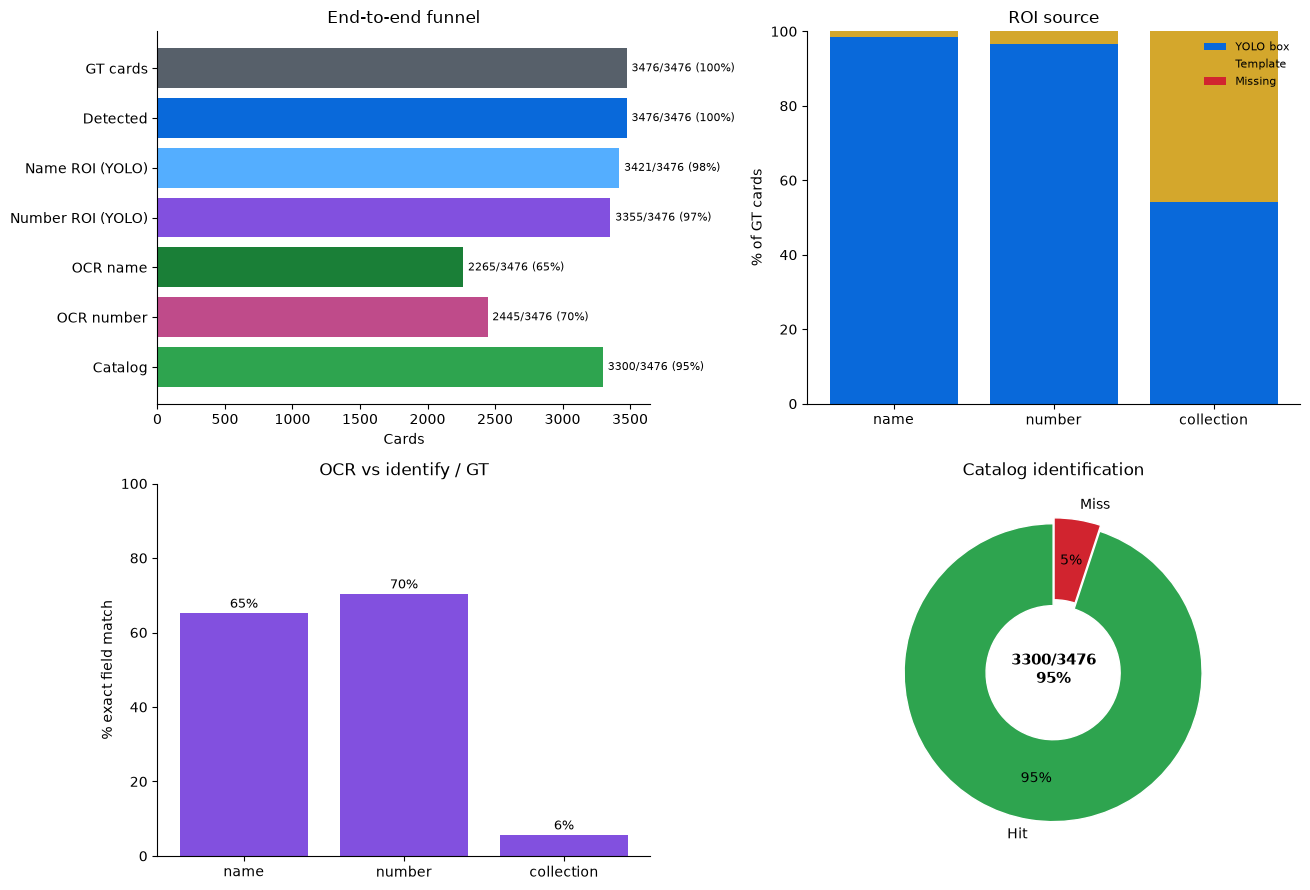

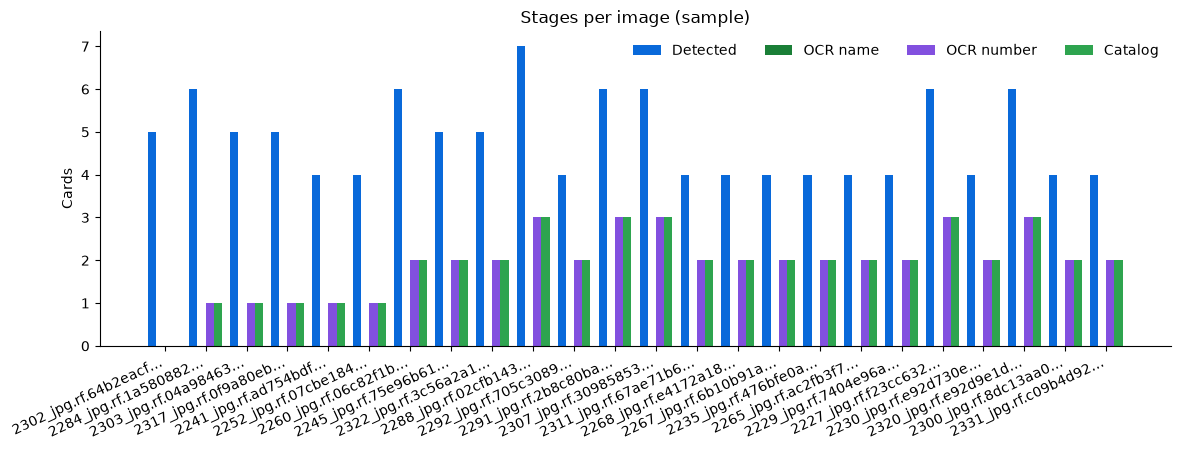

Figures: C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\output\pipeline_acertos.png
         C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\output\pipeline_acertos_etapas.png


In [28]:
gt_mask = (eval_df["gt_name"].astype(str).str.strip().str.len() > 0)
if "gt_number" in eval_df.columns:
    gt_mask = gt_mask | (eval_df["gt_number"].astype(str).str.strip().str.len() > 0)
gt_rows = eval_df[gt_mask].copy()
if "ok" in gt_rows.columns:
    gt_rows["id_ok"] = gt_rows["ok"].astype(bool)
else:
    gt_rows["id_ok"] = False
if "ocr_number_ok" in gt_rows.columns:
    gt_rows["ocr_hit"] = gt_rows["ocr_number_ok"].astype(bool)
else:
    gt_rows["ocr_hit"] = False

OCR_YAML = REPO / "data" / "roi" / "data.yaml"
roi_map_rows = []
test_images = OCR_YAML.parent / "test" / "images"
if IDENTIFY_MODE:
    print("Identify run — skip ROI YOLO val (see train_roi.ipynb).")
elif OCR_YAML.is_file() and test_images.is_dir() and any(test_images.iterdir()):
    try:
        roi_val = roi_model.val(
            data=str(OCR_YAML),
            split="test",
            imgsz=800,
            conf=OCR_CONF,
            device=DEVICE,
            verbose=False,
            plots=False,
            project=str(REPO / "src" / "roi" / "runs"),
            name="roi-pipeline-val",
            exist_ok=True,
        )
        met = getattr(roi_val, "obb", None) or getattr(roi_val, "box", None)
        if met is not None:
            print("ROI detector — YOLO val on ocr/data test")
            print(f"  mAP@0.50      {float(met.map50):.3f}")
            print(f"  mAP@0.50:0.95 {float(met.map):.3f}")
            names = getattr(roi_val, "names", None) or {0: "colection", 1: "name", 2: "number"}
            maps50 = getattr(met, "ap50", None)
            if maps50 is not None:
                for i, ap in enumerate(np.atleast_1d(np.asarray(maps50, dtype=float))):
                    label = names.get(i, i) if isinstance(names, dict) else names[i]
                    roi_map_rows.append(
                        {"stage": "ROI detector (test set)", "metric": f"AP50 {label}", "value": float(ap)}
                    )
                    print(f"  AP50 {str(label):<12} {float(ap):.3f}")
            roi_map_rows.extend(
                [
                    {"stage": "ROI detector (test set)", "metric": "mAP@0.50", "value": float(met.map50)},
                    {"stage": "ROI detector (test set)", "metric": "mAP@0.50:0.95", "value": float(met.map)},
                ]
            )
    except Exception as exc:
        print(f"ROI YOLO val skipped: {type(exc).__name__}: {exc}")
else:
    print("No ROI test images — skip YOLO mAP. Coverage below is from the PDF pipeline.")

if gt_rows.empty:
    print("No ground-truth rows to score.")
else:
    n_gt = len(gt_rows)
    n_det = int(gt_rows["detected"].sum()) if "detected" in gt_rows.columns else int((gt_rows["uid"].astype(str).str.len() > 0).sum())
    n_id_ok = int(gt_rows["id_ok"].sum())
    n_ocr_name = int(gt_rows["ocr_name_ok"].sum()) if "ocr_name_ok" in gt_rows.columns else 0
    n_ocr_num = int(gt_rows["ocr_number_ok"].sum()) if "ocr_number_ok" in gt_rows.columns else int(gt_rows["ocr_hit"].sum())
    n_ocr_set = int(gt_rows["ocr_set_ok"].sum()) if "ocr_set_ok" in gt_rows.columns else 0
    n_roi_name = int((gt_rows["roi_name_src"] == "det").sum()) if "roi_name_src" in gt_rows.columns else 0
    n_roi_num = int((gt_rows["roi_number_src"] == "det").sum()) if "roi_number_src" in gt_rows.columns else 0

    def roi_rate(field: str, kind: str) -> float:
        col = f"roi_{field}_src"
        if col not in gt_rows.columns:
            return 0.0
        return float((gt_rows[col] == kind).mean())

    summary_rows = list(roi_map_rows)
    summary_rows.extend(
        [
            {"stage": "Cards", "metric": "detected / GT (recall)", "value": n_det / n_gt},
            {"stage": "Cards", "metric": "precision (IoU match)", "value": n_det / max(n_det + int((~gt_mask).sum()), 1)},
            {"stage": "Cards", "metric": "F1 detection", "value": (2 * (n_det / n_gt) * (n_det / max(n_det + int((~gt_mask).sum()), 1))) / max((n_det / n_gt) + (n_det / max(n_det + int((~gt_mask).sum()), 1)), 1e-9)},
            {"stage": "Cards", "metric": "extra detections (no GT)", "value": int((~gt_mask).sum())},
            {"stage": "ROI name", "metric": "% detector box", "value": roi_rate("name", "det")},
            {"stage": "ROI name", "metric": "% template fallback", "value": roi_rate("name", "template")},
            {"stage": "ROI number", "metric": "% detector box", "value": roi_rate("number", "det")},
            {"stage": "ROI number", "metric": "% template fallback", "value": roi_rate("number", "template")},
            {"stage": "ROI collection", "metric": "% detector box", "value": roi_rate("collection", "det")},
            {"stage": "ROI collection", "metric": "% template fallback", "value": roi_rate("collection", "template")},
            {"stage": "OCR name", "metric": "accuracy", "value": n_ocr_name / n_gt},
            {"stage": "OCR name", "metric": "mean CER", "value": float(gt_rows["cer_name"].mean()) if "cer_name" in gt_rows.columns else float("nan")},
            {"stage": "OCR number", "metric": "accuracy", "value": n_ocr_num / n_gt},
            {"stage": "OCR number", "metric": "mean CER", "value": float(gt_rows["cer_number"].mean()) if "cer_number" in gt_rows.columns else float("nan")},
            {"stage": "OCR collection", "metric": "accuracy vs set name", "value": n_ocr_set / n_gt},
            {"stage": "End-to-end", "metric": "catalog hit", "value": n_id_ok / n_gt},
        ]
    )
    metrics_df = pd.DataFrame(summary_rows)
    metrics_path = OUT_DIR / "pipeline_metrics.csv"
    metrics_df.to_csv(metrics_path, index=False, encoding="utf-8")
    print("\nPipeline metrics")
    display(metrics_df)
    print("CSV:", metrics_path)

    fig, axes = plt.subplots(2, 2, figsize=(13.2, 9.0))

    funnel_labels = [
        "GT cards",
        "Detected",
        "Name ROI (YOLO)",
        "Number ROI (YOLO)",
        "OCR name",
        "OCR number",
        "Catalog",
    ]
    funnel_vals = [n_gt, n_det, n_roi_name, n_roi_num, n_ocr_name, n_ocr_num, n_id_ok]
    colors_f = ["#57606a", "#0969da", "#54aeff", "#8250df", "#1a7f37", "#bf4b8a", "#2ea44f"]
    axes[0, 0].barh(funnel_labels[::-1], funnel_vals[::-1], color=colors_f[::-1])
    axes[0, 0].set_title("End-to-end funnel")
    axes[0, 0].set_xlabel("Cards")
    for y, v in enumerate(funnel_vals[::-1]):
        axes[0, 0].text(v + n_gt * 0.01, y, f"{v}/{n_gt} ({100 * v / n_gt:.0f}%)", va="center", fontsize=8)
    axes[0, 0].spines["top"].set_visible(False)
    axes[0, 0].spines["right"].set_visible(False)

    fields = ["name", "number", "collection"]
    det_s = [roi_rate(f, "det") * 100 for f in fields]
    tmpl_s = [roi_rate(f, "template") * 100 for f in fields]
    miss_s = [max(0.0, 100 - d - t) for d, t in zip(det_s, tmpl_s)]
    x = np.arange(len(fields))
    axes[0, 1].bar(x, det_s, color="#0969da", label="YOLO box")
    axes[0, 1].bar(x, tmpl_s, bottom=det_s, color="#d4a72c", label="Template")
    axes[0, 1].bar(x, miss_s, bottom=np.array(det_s) + np.array(tmpl_s), color="#d1242f", label="Missing")
    axes[0, 1].set_xticks(x)
    axes[0, 1].set_xticklabels(fields)
    axes[0, 1].set_ylim(0, 100)
    axes[0, 1].set_ylabel("% of GT cards")
    axes[0, 1].set_title("ROI source")
    axes[0, 1].legend(frameon=False, fontsize=8)
    axes[0, 1].spines["top"].set_visible(False)
    axes[0, 1].spines["right"].set_visible(False)

    ocr_acc = [100 * n_ocr_name / n_gt, 100 * n_ocr_num / n_gt, 100 * n_ocr_set / n_gt]
    axes[1, 0].bar(fields, ocr_acc, color="#8250df")
    axes[1, 0].set_ylim(0, 100)
    axes[1, 0].set_ylabel("% exact field match")
    axes[1, 0].set_title("OCR vs identify / GT")
    for i, v in enumerate(ocr_acc):
        axes[1, 0].text(i, v + 1.5, f"{v:.0f}%", ha="center", fontsize=9)
    axes[1, 0].spines["top"].set_visible(False)
    axes[1, 0].spines["right"].set_visible(False)

    sizes = [n_id_ok, n_gt - n_id_ok]
    axes[1, 1].pie(
        sizes,
        labels=["Hit", "Miss"],
        colors=["#2ea44f", "#d1242f"],
        autopct="%1.0f%%",
        startangle=90,
        explode=(0.02, 0.02),
        wedgeprops={"width": 0.55, "edgecolor": "white"},
        pctdistance=0.72,
    )
    axes[1, 1].set_title("Catalog identification")
    axes[1, 1].text(0, 0, f"{n_id_ok}/{n_gt}\n{100 * n_id_ok / n_gt:.0f}%", ha="center", va="center", fontsize=11, fontweight="bold")

    fig.tight_layout()
    fig_path = OUT_DIR / "pipeline_acertos.png"
    fig.savefig(fig_path, dpi=140, bbox_inches="tight")
    plt.show()

    def short_name(name: str) -> str:
        name = str(name).replace("WhatsApp Image ", "WA ").removesuffix(".jpg")
        return name if len(name) <= 22 else name[:20] + "…"

    agg = {"total": ("id_ok", "size"), "catalog": ("id_ok", "sum")}
    if "detected" in gt_rows.columns:
        agg["detected"] = ("detected", "sum")
    if "ocr_name_ok" in gt_rows.columns:
        agg["ocr_name"] = ("ocr_name_ok", "sum")
    if "ocr_number_ok" in gt_rows.columns:
        agg["ocr_number"] = ("ocr_number_ok", "sum")
    per_img = gt_rows.groupby("image", sort=False).agg(**agg).reset_index()
    if "catalog" in per_img.columns and len(per_img) > 24:
        per_img = per_img.assign(_rate=per_img["catalog"] / per_img["total"].clip(lower=1)).sort_values("_rate").head(24)
    per_img["label"] = per_img["image"].map(short_name)
    fig2, ax = plt.subplots(figsize=(12, 4.6))
    x = np.arange(len(per_img))
    series = [
        ("detected", "#0969da", "Detected"),
        ("ocr_name", "#1a7f37", "OCR name"),
        ("ocr_number", "#8250df", "OCR number"),
        ("catalog", "#2ea44f", "Catalog"),
    ]
    series = [(col, color, lab) for col, color, lab in series if col in per_img.columns]
    width = 0.8 / max(len(series), 1)
    for i, (col, color, lab) in enumerate(series):
        ax.bar(x + (i - (len(series) - 1) / 2) * width, per_img[col], width, color=color, label=lab)
    ax.set_xticks(x)
    ax.set_xticklabels(per_img["label"], rotation=25, ha="right")
    ax.set_ylabel("Cards")
    ax.set_title("Stages per image (sample)")
    ax.legend(frameon=False, ncol=len(series), loc="upper right")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    fig2.tight_layout()
    fig2_path = OUT_DIR / "pipeline_acertos_etapas.png"
    fig2.savefig(fig2_path, dpi=140, bbox_inches="tight")
    plt.show()
    print("Figures:", fig_path)
    print("        ", fig2_path)


## 8. PDFs de adivinhação

Dois PDFs de recorte com o palpite do catálogo vs GT: `03_acertos.pdf` e `03_erros.pdf`. Em ambos as faixas de ROI (verde = nome, azul = número, amarelo = coleção) vão no recorte. No PDF de erros cada carta tem **LIDO × CORRETO** ao lado. Junto com o OBB, ficam em `output/pdfs/`.


In [29]:
from IPython.display import Markdown, display


def _arquivo(name) -> str:
    return str(name).split('_jpg')[0]


error_rows = pd.DataFrame()
if 'gt_rows' in globals() and len(gt_rows):
    if 'id_ok' in gt_rows.columns:
        error_rows = gt_rows.loc[~gt_rows['id_ok'].astype(bool)].reset_index(drop=True)
    elif 'ok' in gt_rows.columns:
        error_rows = gt_rows.loc[~gt_rows['ok'].astype(bool)].reset_index(drop=True)

n_err = len(error_rows)
print(f'{n_err} carta(s) errada(s)')
if n_err == 0:
    print('Nenhum erro de identificacao.')
else:
    pd.set_option('display.max_colwidth', None)
    pd.set_option('display.max_rows', None)
    table = error_rows.copy()
    table['arquivo'] = table['image'].astype(str).map(_arquivo) if 'image' in table.columns else ''
    table['nome_lido'] = table.get('ocr_name', '')
    table['nome_correto'] = table.get('gt_name', '')
    table['numero_lido'] = table.get('ocr_number', '')
    table['numero_correto'] = table.get('gt_number', '')
    table['set_lido'] = table.get('ocr_collection', '')
    table['set_correto'] = table.get('gt_set', '')
    cols = [c for c in (
        'arquivo', 'detected', 'iou',
        'nome_lido', 'nome_correto',
        'numero_lido', 'numero_correto',
        'set_lido', 'set_correto',
        'match_name', 'match_number', 'match_set',
    ) if c in table.columns]
    display(Markdown(f'**Tabela: {n_err} erros (lido x correto)**'))
    display(table[cols].reset_index(drop=True))
    err_csv = OUT_DIR / 'pipeline_errors.csv'
    table.to_csv(err_csv, index=False, encoding='utf-8')
    print('CSV:', err_csv)

for label, path in (
    ('OBB', OUT_PDF_DIR / '01_obb.pdf'),
    ('Acertos', OUT_PDF_DIR / '03_acertos.pdf'),
    ('Erros', OUT_PDF_DIR / '03_erros.pdf'),
):
    print(f'PDF {label}: {path}  exists={path.is_file()}')


176 carta(s) errada(s)


**Tabela: 176 erros (lido x correto)**

,arquivo,detected,iou,nome_lido,nome_correto,numero_lido,numero_correto,set_lido,set_correto,match_name,match_number,match_set
0,1005,True,0.971,,Weedle,,5/108,,xy12,Alakazam,1/130,B2
1,1008,True,0.974,,Luxray TURBO,,47/122,,xy9,Alakazam,1/130,B2
2,1014,True,0.975,,Machamp TURBO,,60/108,,xy12,Alakazam,1/130,B2
3,1022,True,0.974,,Pyroar TURBO,,24/114,,xy11,Alakazam,1/130,B2
4,1032,True,0.972,Energia UnitáriaE,Energia Unitaria LightningPsychicMetal,001/156,171/156,,sm5,Énergie Plante,1/8,SVE
5,1041,True,0.972,,Xerneas TURBO,,82/114,,xy11,Alakazam,1/130,B2
6,1090,True,0.979,M,Hydreigon BREAK,,87/114,,xy11,Muk,13/62,FO
7,2001,True,0.984,,Aluna,,277/264,,swsh8,Alakazam,1/130,B2
8,2001,True,0.969,,Sorbus,,149/189,,swsh10,Alakazam,1/130,B2
9,2002,True,0.962,MERGIA,Energia de Agua,,231/198,,swsh6,Margit,87/111,N1


CSV: C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\output\pipeline_errors.csv
PDF OBB: C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\output\pdfs\01_obb.pdf  exists=True
PDF Acertos: C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\output\pdfs\03_acertos.pdf  exists=True
PDF Erros: C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\output\pdfs\03_erros.pdf  exists=True
